In [6]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms

# Device will determine whether to run the training on GPU or CPU.
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


load data

In [1]:
import os 
import pandas as pd

file_path = '../HW2/HW2_MNIST_train/'

# 讀取所有 txt 檔案，建立 DataFrame
data_list = []
for txt_file in os.listdir(file_path):
    if txt_file.endswith(".txt"):
        img_name = txt_file.replace(".txt", ".png")  
        img_path = os.path.join(file_path, img_name)
        txt_path = os.path.join(file_path, txt_file)
        
        with open(txt_path, "r") as f:
            label = f.read().strip().split('\t')  # 讀取標籤
            label.insert(0, img_path)
            data_list.append(label)
        

# 轉成 DataFrame
df = pd.DataFrame(data_list, columns=["img_path", "label", "upper_left_x", "upper_left_y", "h", "w"])

In [2]:
df.head()

,img_path,label,upper_left_x,upper_left_y,h,w
0,../HW2/HW2_MNIST_train/0000000.png,0,0.3671875,0.3203125,0.21875,0.21875
1,../HW2/HW2_MNIST_train/0000001.png,0,0.5390625,0.53125,0.4375,0.4375
2,../HW2/HW2_MNIST_train/0000002.png,0,0.7734375,0.4296875,0.21875,0.21875
3,../HW2/HW2_MNIST_train/0000003.png,0,0.515625,0.2421875,0.4375,0.4375
4,../HW2/HW2_MNIST_train/0000005.png,0,0.2890625,0.5,0.4375,0.4375


dataset and dataloader in pytorch

In [3]:
from PIL import Image
import cv2
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms

# 定義 PyTorch Dataset
class ImageDataset(Dataset):
    # fetch information form the dataframe and transform the image
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        img_path = self.dataframe.iloc[idx, 0]
        label = int(self.dataframe.iloc[idx, 1])

        image = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE) # grayscale
        h, w = image.shape[:2]
        # get the bounding box
        bbox = (
            float(self.dataframe.iloc[idx, 2]),
            float(self.dataframe.iloc[idx, 3]),
            float(self.dataframe.iloc[idx, 4]),
            float(self.dataframe.iloc[idx, 5])
        )
        # image = move_bounding_box_to_center(image, bbox)

        # convert to PIL image
        image = Image.fromarray(image)

        if self.transform:
            image = self.transform(image)

        return image, label

transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),  # <-- 把灰階轉成 RGB 格式
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])


In [5]:
print(df['label'].value_counts())

label
1    10835
0    10785
7    10007
3     9812
2     9531
9     9524
6     9474
8     9427
4     9314
5     8687
Name: count, dtype: int64


We split the provided dataset (HW2_MNIST_train.zip) into a training set (70%) and a validation set (30%). We used the CLIP model to classify images and report Top-1 and Top-3 accuracy on both the training and validation sets.

In [4]:
from sklearn.model_selection import train_test_split
import cv2
# Split the dataset into training and validation sets with stratification to ensure even label distribution
train_df, val_df = train_test_split(df, test_size=0.3, random_state=3, stratify=df['label'])

# Define the batch size
batch_size = 32

# create dataset and dataloader
train_dset = ImageDataset(dataframe=train_df, transform=transform)
train_dataloader = DataLoader(train_dset, batch_size=batch_size, shuffle=True)
val_dset = ImageDataset(dataframe=val_df, transform=transform)
val_dataloader = DataLoader(val_dset, batch_size=batch_size, shuffle=False)

# 測試資料加載
for images, labels in train_dataloader:
    print(images.shape)  # 輸出: (batch_size, channels, height, width)
    print(labels.shape)  # 輸出: (batch_size,)
    break

torch.Size([32, 3, 224, 224])
torch.Size([32])


CLIP model

In [7]:
from transformers import CLIPModel, CLIPProcessor
class CustomCLIPClassifier(nn.Module):
    def __init__(self, num_classes=10, pretrained_model="openai/clip-vit-base-patch32"):
        super(CustomCLIPClassifier, self).__init__()
        self.clip = CLIPModel.from_pretrained(pretrained_model)
        self.processor = CLIPProcessor.from_pretrained(pretrained_model)

        # Freeze CLIP backbone if you don't want fine-tuning
        for param in self.clip.parameters():
            param.requires_grad = False

        # You can use either image or text branch; here we use image
        self.image_projector = self.clip.vision_model   # call image encoder only
        self.linear = nn.Linear(self.clip.vision_model.config.hidden_size, num_classes)

    def forward(self, images):
        # images: tensor in shape [B, 3, H, W], float
        vision_outputs = self.image_projector(pixel_values=images)
        pooled_output = vision_outputs.pooler_output  # [B, hidden_dim]
        logits = self.linear(pooled_output)           # [B, num_classes]
        return logits

In [8]:
model = CustomCLIPClassifier(num_classes=10).to(device)

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


training

In [9]:
from tqdm import tqdm # for training progress bar, if not used, can be removed

TOPK = 3
Epoch = 3
learning_rate = 1e-4

loss = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

loss_values = []
valid_loss_values = []
train_accuracy_values = []
valid_accuracy_values = []
train_topk_accuracies = []
valid_topk_accuracies = []
best_val_acc = 0

for epoch in range(1, Epoch+1):
    model.train()
    accuracy = 0.0
    topk_accuracy = 0.0
    train_loss = 0.0

    # tqdm is used to show the progress bar
    print(f"\n[Epoch {epoch}] Training...")
    train_bar = tqdm(train_dataloader)

    # if using tqdm, replace the dataloader with tqdm
    # else put train_dataloader directly in the for loop
    for i, (images, labels) in enumerate(train_bar):
        # move data to device
        X_train = images.to(device)
        Y_train = labels.to(device).long()
        
        # X_train = X_train.squeeze(1)
        # zero gradients
        optimizer.zero_grad()
        # forward pass
        Y_pred = model(X_train)
        # compute loss
        l = loss(Y_pred, Y_train)
        # backward pass
        l.backward()
        # update weights
        optimizer.step()

        # calculate accuracy
        predictions = Y_pred.argmax(dim=1)  # Get the predicted class index
        corrections = (predictions == Y_train).sum().item()
        accuracy += corrections
        # calculate top-k accuracy
        topk = torch.topk(Y_pred, k=TOPK, dim=1).indices
        topk_correct = torch.any(topk == Y_train.unsqueeze(1), dim=1).sum().item()
        topk_accuracy += topk_correct
        # update the training "total" loss
        train_loss += (l.item() * Y_train.size(0))  # accumulate loss


        # print the loss and accuracy for every batch
        train_bar.set_description(
            f"Loss: {l.item():.4f} | Top1-Acc: {corrections/Y_train.size(0):.4f} | Top{TOPK}-Acc: {topk_correct/Y_train.size(0):.4f}"
        )
        # print every batch_size batches
        # print(f"In Epoch {epoch}: \
        #         Batch {(i+1)*batch_size}/{len(train_dataloader.dataset)}: \
        #             Loss: {l.item():.4f}, \
        #             Top1-Accuracy: {corrections/Y_train.size(0):.4f}, \
        #             Top3-Accuracy: {topk_correct/Y_train.size(0):.4f}"
        #       )
        
    # average the loss and accuracy
    accuracy /= len(train_dataloader.dataset)
    topk_accuracy /= len(train_dataloader.dataset)
    train_loss /= len(train_dataloader.dataset)
    print(f"✅ Epoch {epoch}: \
            Train Loss: {train_loss:.4f}, Top1-Accuracy: {accuracy:.4f}, Top3-Accuracy: {topk_accuracy:.4f}")

    # store the loss and accuracy and top3 accuracy
    loss_values.append(train_loss)
    train_accuracy_values.append(accuracy)
    train_topk_accuracies.append(topk_accuracy)

    # evaluate the model
    model.eval()
    valid_acc = 0.0
    valid_topk_accuracy = 0.0
    valid_loss = 0.0

    # tqdm is used to show the progress bar
    print(f"[Epoch {epoch}] Validating...")
    val_bar = tqdm(val_dataloader)

    # iterate through the validation set
    # if using tqdm, replace the dataloader with tqdm
    # else put valid_dataloader directly in the for loop
    for images, labels in val_bar:
        # move data to device
        X_test = images.to(device).float()
        Y_test = labels.to(device).long()
        # X_test = X_test.squeeze(1)
        Y_pred = model(X_test)
        # compute loss
        l = loss(Y_pred, Y_test)
        # calculate accuracy
        predictions = Y_pred.argmax(dim=1)  # Get the predicted class index
        valid_acc += (predictions == Y_test).sum().item()
        # calculate top-k accuracy
        topk = torch.topk(Y_pred, k=TOPK, dim=1).indices
        topk_correct = torch.any(topk == Y_test.unsqueeze(1), dim=1).sum().item()
        valid_topk_accuracy += topk_correct
        # update the validation "total" loss
        valid_loss += l.item() * X_test.size(0)  # accumulate loss
        
    # store the loss and accuracy
    valid_acc /= len(val_dataloader.dataset)
    valid_topk_accuracy /= len(val_dataloader.dataset)
    valid_loss /= len(val_dataloader.dataset)
    valid_loss_values.append(valid_loss)
    valid_accuracy_values.append(valid_acc)
    valid_topk_accuracies.append(valid_topk_accuracy)

    # print the loss and accuracy for every batch
    val_bar.set_description(
            f"🧪 Loss: {valid_loss:.4f} | Top1-Acc: {valid_acc:.4f} | Top{TOPK}-Acc: {valid_topk_accuracy:.4f}"
        )
    # print(f"🧪 Epoch {epoch}: \
    #         Validation Loss: {valid_loss:.4f}, \
    #         Top1-Accuracy: {valid_acc:.4f}, \
    #         Top3-Accuracy: {valid_topk_accuracy:.4f}")
    
    if best_val_acc < valid_acc:
        # update the best validation accuracy
        best_val_acc = valid_acc
        # save the model if the validation loss is the best so far
        torch.save(model.state_dict(), 'clip.pth')
        print(f"📦 Best model saved with Top1 Val Accuracy: {best_val_acc:.4f}")


[Epoch 1] Training...


Loss: 0.8327 | Top1-Acc: 0.8235 | Top3-Acc: 0.9412: 100%|██████████| 2131/2131 [32:08<00:00,  1.11it/s]


✅ Epoch 1:             Train Loss: 1.0480, Top1-Accuracy: 0.7759, Top3-Accuracy: 0.9180
[Epoch 1] Validating...


100%|██████████| 914/914 [12:56<00:00,  1.18it/s]


📦 Best model saved with Top1 Val Accuracy: 0.8979

[Epoch 2] Training...


...

📦 Best model saved with Top1 Val Accuracy: 0.9373

[Epoch 3] Training...


Loss: 0.1652 | Top1-Acc: 0.9412 | Top3-Acc: 1.0000: 100%|██████████| 2131/2131 [26:34<00:00,  1.34it/s]


✅ Epoch 3:             Train Loss: 0.2884, Top1-Accuracy: 0.9426, Top3-Accuracy: 0.9900
[Epoch 3] Validating...


100%|██████████| 914/914 [06:04<00:00,  2.51it/s]


📦 Best model saved with Top1 Val Accuracy: 0.9513


loss and accuracy graph

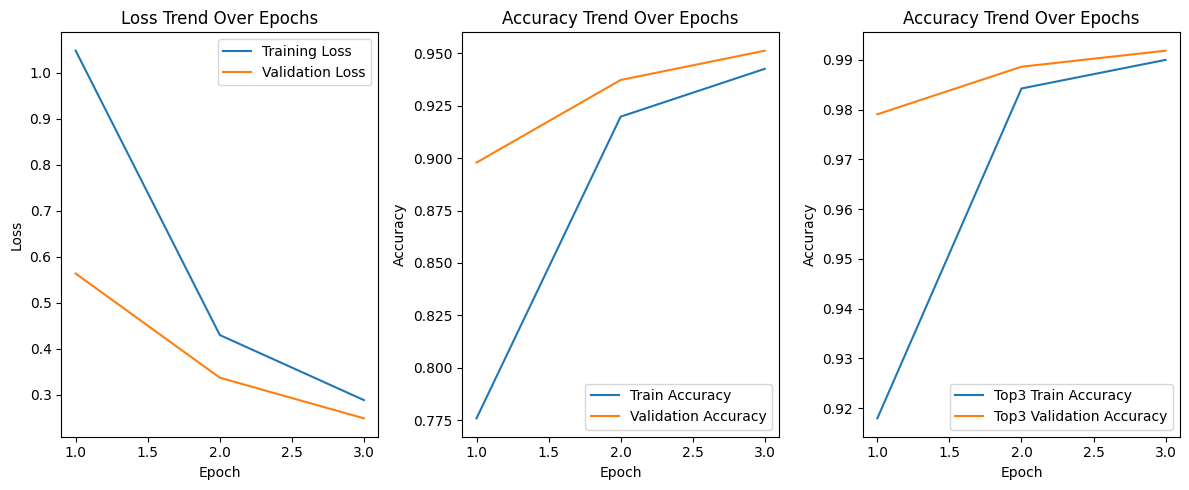

In [12]:
from matplotlib import pyplot as plt
fig, ax = plt.subplots(1, 3, figsize=(12, 5))

# plot the loss trend
ax[0].plot(range(1, Epoch+1), loss_values, label='Training Loss')
ax[0].plot(range(1, Epoch+1), valid_loss_values, label='Validation Loss')
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('Loss')
ax[0].set_title('Loss Trend Over Epochs')
ax[0].legend()

# plot the accuracy trend
ax[1].plot(range(1, Epoch+1), train_accuracy_values, label='Train Accuracy')
ax[1].plot(range(1, Epoch+1), valid_accuracy_values, label='Validation Accuracy')
ax[1].set_xlabel('Epoch')
ax[1].set_ylabel('Accuracy')
ax[1].set_title('Accuracy Trend Over Epochs')
ax[1].legend()

# plot the topk accuracy trend
ax[2].plot(range(1, Epoch+1), train_topk_accuracies, label='Top3 Train Accuracy')
ax[2].plot(range(1, Epoch+1), valid_topk_accuracies, label='Top3 Validation Accuracy')
ax[2].set_xlabel('Epoch')
ax[2].set_ylabel('Accuracy')
ax[2].set_title('Accuracy Trend Over Epochs')
ax[2].legend()

plt.tight_layout()
plt.show()

evaluate on all MNIST_train

In [17]:
from tqdm import tqdm # for training progress bar, if not used, can be removed

# create dataset and dataloader
all_train_dset = ImageDataset(dataframe=df, transform=transform)
all_train_dataloader = DataLoader(all_train_dset, batch_size=batch_size, shuffle=False)

# parameters
TOPK = 3
loss = nn.CrossEntropyLoss()

# load the best model
model = CustomCLIPClassifier(num_classes=10).to(device)
model.load_state_dict(torch.load('clip.pth'))
model.eval()


accuracy = 0.0
topk_accuracy = 0.0
all_train_loss = 0.0

# tqdm is used to show the progress bar
print(f"Testing...")
train_bar = tqdm(all_train_dataloader)

# if using tqdm, replace the dataloader with tqdm
# else put train_dataloader directly in the for loop
for i, (images, labels) in enumerate(train_bar):
    # move data to device
    X_train = images.to(device)
    Y_train = labels.to(device).long()
    
    # forward pass
    Y_pred = model(X_train)
    # compute loss
    l = loss(Y_pred, Y_train)

    # calculate accuracy
    predictions = Y_pred.argmax(dim=1)  # Get the predicted class index
    corrections = (predictions == Y_train).sum().item()
    accuracy += corrections
    # calculate top-k accuracy
    topk = torch.topk(Y_pred, k=TOPK, dim=1).indices
    topk_correct = torch.any(topk == Y_train.unsqueeze(1), dim=1).sum().item()
    topk_accuracy += topk_correct
    # update the training "total" loss
    all_train_loss += (l.item() * Y_train.size(0))  # accumulate loss

    # print the loss and accuracy for every batch
    train_bar.set_description(
        f"Loss: {l.item():.4f} | Top1-Acc: {corrections/Y_train.size(0):.4f} | Top{TOPK}-Acc: {topk_correct/Y_train.size(0):.4f}"
    )

# average the loss and accuracy
accuracy /= len(all_train_dataloader.dataset)
topk_accuracy /= len(all_train_dataloader.dataset)
all_train_loss /= len(all_train_dataloader.dataset)
print(f"✅ \
        Train Loss: {all_train_loss:.4f}, Top1-Accuracy: {accuracy:.4f}, Top3-Accuracy: {topk_accuracy:.4f}")

Testing...


Loss: 0.1399 | Top1-Acc: 1.0000 | Top3-Acc: 1.0000: 100%|██████████| 3044/3044 [20:11<00:00,  2.51it/s]

✅         Train Loss: 0.2486, Top1-Accuracy: 0.9501, Top3-Accuracy: 0.9918


testing

In [13]:
import torch
import os
from torchvision import transforms
from PIL import Image
import pandas as pd

# 設定裝置
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 轉換函數 (與 train 相同)
transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),  # 灰階轉 RGB
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# 測試資料夾
test_folder = '../HW2/HW2_MNIST_test/'
test_images = sorted(os.listdir(test_folder))  # 確保順序一致

# 儲存預測結果
results = []

# 載入模型
model.load_state_dict(torch.load("clip.pth"))
model.to(device)
model.eval()

# 預測每張圖片
for img_name in test_images:
    img_path = os.path.join(test_folder, img_name)
    image = Image.open(img_path).convert("L")  # 轉成灰階
    image = transform(image).unsqueeze(0).to(device)  # 增加 batch 維度

    with torch.no_grad():
        output = model(image)
        probs = torch.nn.functional.softmax(output, dim=1)  # 機率分布
        top3_probs, top3_preds = torch.topk(probs, k=3, dim=1)  # Top-3

        top1_pred = top3_preds[0][0].item()
        top3_pred_list = top3_preds[0].cpu().tolist()  # 轉成 list 儲存

    # 儲存結果
    results.append({
        "image": img_name,
        "top1": top1_pred,
        "top3": top3_pred_list
    })

# 儲存成 CSV
df_results = pd.DataFrame(results)
output_csv = "HW4_prob1_CLIP.csv"
df_results.to_csv(output_csv, index=False)

print(f"預測結果已儲存至 {output_csv}")

預測結果已儲存至 HW4_prob1_CLIP.csv
